Device: cuda

Dataset: MNIST


100%|██████████| 9.91M/9.91M [00:00<00:00, 34.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.20MB/s]



  ── Subset 0.2% (120 samples) ──
    seed=42 | Top-1=15.66% | Macro-F1=0.0701 | 5s
    seed=123 | Top-1=24.07% | Macro-F1=0.1484 | 3s
    seed=456 | Top-1=15.16% | Macro-F1=0.0612 | 3s
    seed=789 | Top-1=21.88% | Macro-F1=0.1609 | 3s
    seed=1011 | Top-1=44.58% | Macro-F1=0.3934 | 3s

  ── Subset 0.5% (300 samples) ──
    seed=42 | Top-1=88.80% | Macro-F1=0.8861 | 4s
    seed=123 | Top-1=62.54% | Macro-F1=0.5834 | 4s
    seed=456 | Top-1=85.94% | Macro-F1=0.8564 | 4s
    seed=789 | Top-1=81.69% | Macro-F1=0.8108 | 4s
    seed=1011 | Top-1=91.53% | Macro-F1=0.9143 | 4s

  ── Subset 1% (600 samples) ──
    seed=42 | Top-1=93.41% | Macro-F1=0.9339 | 4s
    seed=123 | Top-1=94.12% | Macro-F1=0.9404 | 4s
    seed=456 | Top-1=95.43% | Macro-F1=0.9537 | 4s
    seed=789 | Top-1=94.54% | Macro-F1=0.9452 | 4s
    seed=1011 | Top-1=95.73% | Macro-F1=0.9568 | 4s

  ── Subset 2% (1200 samples) ──
    seed=42 | Top-1=96.65% | Macro-F1=0.9662 | 6s
    seed=123 | Top-1=96.37% | Macro-F1=0.9638 | 

100%|██████████| 170M/170M [00:07<00:00, 21.4MB/s] 



  ── Subset 0.2% (100 samples) ──
    seed=42 | Top-1=18.53% | Macro-F1=0.1570 | 5s
    seed=123 | Top-1=26.53% | Macro-F1=0.2405 | 5s
    seed=456 | Top-1=26.29% | Macro-F1=0.2284 | 5s
    seed=789 | Top-1=23.26% | Macro-F1=0.2107 | 5s
    seed=1011 | Top-1=21.83% | Macro-F1=0.1997 | 5s

  ── Subset 0.5% (250 samples) ──
    seed=42 | Top-1=36.16% | Macro-F1=0.3613 | 6s
    seed=123 | Top-1=35.27% | Macro-F1=0.3400 | 6s
    seed=456 | Top-1=34.93% | Macro-F1=0.3341 | 6s
    seed=789 | Top-1=27.99% | Macro-F1=0.2638 | 6s
    seed=1011 | Top-1=31.25% | Macro-F1=0.2850 | 6s

  ── Subset 1% (500 samples) ──
    seed=42 | Top-1=39.91% | Macro-F1=0.3983 | 7s
    seed=123 | Top-1=40.44% | Macro-F1=0.3997 | 7s
    seed=456 | Top-1=40.11% | Macro-F1=0.3774 | 7s
    seed=789 | Top-1=39.71% | Macro-F1=0.3897 | 7s
    seed=1011 | Top-1=40.21% | Macro-F1=0.3991 | 7s

  ── Subset 2% (1000 samples) ──
    seed=42 | Top-1=50.44% | Macro-F1=0.4943 | 10s
    seed=123 | Top-1=48.87% | Macro-F1=0.4848 |

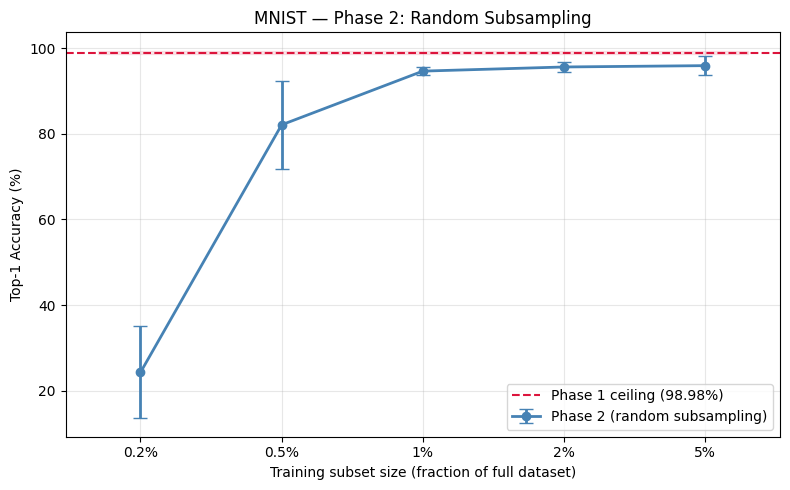

Saved: /kaggle/working/plots/phase2_MNIST_accuracy_curve.png


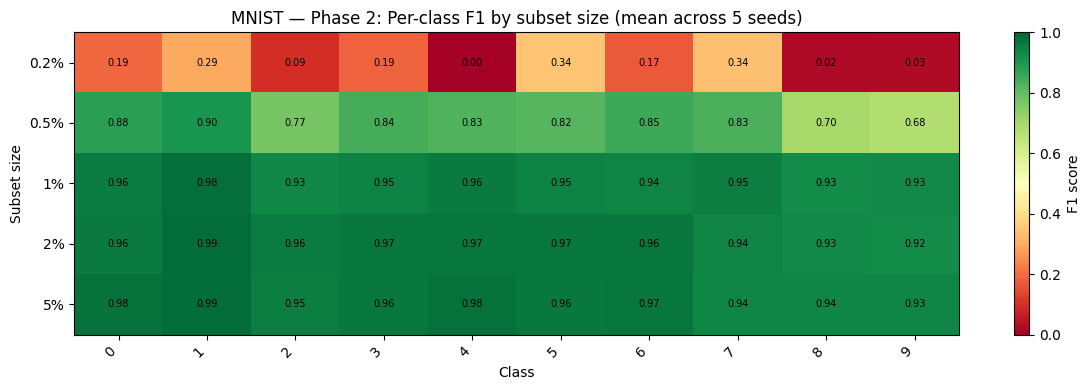

Saved: /kaggle/working/plots/phase2_MNIST_perclass_f1.png


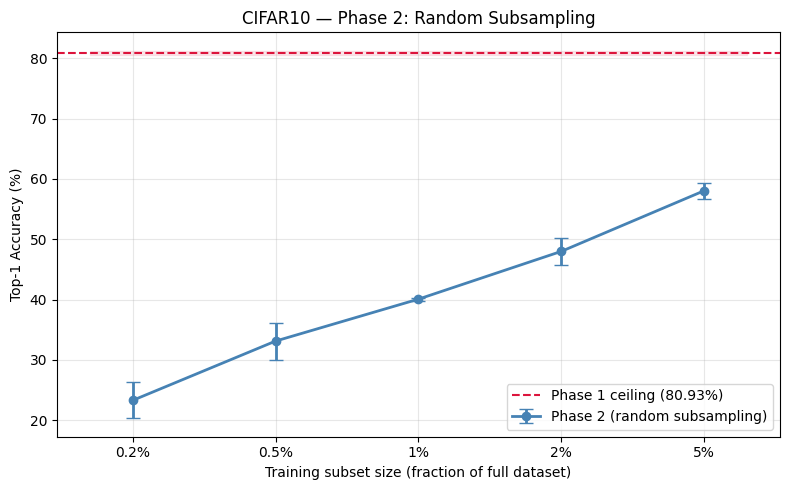

Saved: /kaggle/working/plots/phase2_CIFAR10_accuracy_curve.png


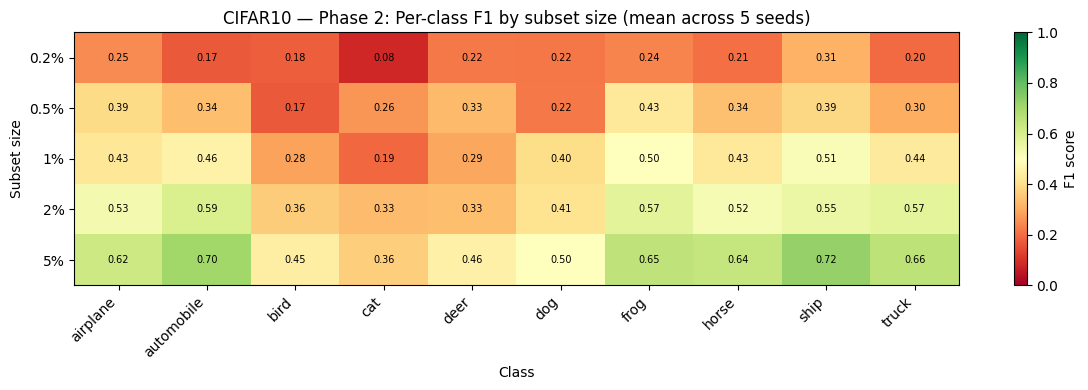

Saved: /kaggle/working/plots/phase2_CIFAR10_perclass_f1.png

Phase 2 complete. All checkpoints, results JSON, and plots saved.
Checkpoints : /kaggle/working/checkpoints
Results JSON: /kaggle/working/results/phase2_results.json
Plots       : /kaggle/working/plots


In [1]:
# ============================================================
# SECTION 1 — IMPORTS & CONFIG
# ============================================================
 
import os, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
 
# ── Fixed constants — never change across phases ──────────────
SEEDS         = [42, 123, 456, 789, 1011]
SUBSET_FRACS  = [0.002, 0.005, 0.01, 0.02, 0.05]
SUBSET_LABELS = ['0.2%', '0.5%', '1%', '2%', '5%']
BATCH_SIZE    = 128
NUM_WORKERS   = 2
EPOCHS        = {'MNIST': 20, 'CIFAR10': 30}
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
 
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
RESULTS_DIR    = '/kaggle/working/results'
PLOT_DIR       = '/kaggle/working/plots'
for d in [CHECKPOINT_DIR, RESULTS_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)
 
 
# ============================================================
# SECTION 2 — SEEDING UTILITIES
#
# set_seed: fixes main process (Python, NumPy, PyTorch, CUDA).
# seed_worker: fixes each DataLoader worker subprocess.
#   Without it, workers use OS-random seeds when num_workers > 0.
#   torch.initial_seed() returns the seed PyTorch assigned that
#   worker; we propagate it to NumPy and Python random.
# cudnn.deterministic: forces deterministic CUDA ops.
# cudnn.benchmark = False: stops CUDA picking a faster but
#   non-deterministic algorithm between runs.
# ============================================================
 
def set_seed(seed: int):
    """Fix all random sources in the main process."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
def seed_worker(worker_id):
    """Called once per DataLoader worker at startup."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
 
 
# ============================================================
# SECTION 3 — TRANSFORMS & DATASET BUILDERS
#
# Identical to Phase 1 — never change across phases.
# MNIST: normalise only, no augmentation.
# CIFAR train: RandomHorizontalFlip + RandomCrop(32,padding=4)
#   + normalise. Test: normalise only.
# Augmentation on test would inflate scores — never do it.
# ============================================================
 
def get_transforms(dataset_name: str, train: bool):
    """Return correct transform pipeline for each dataset and split."""
    if dataset_name == 'MNIST':
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
    else:  # CIFAR10
        if train:
            return transforms.Compose([
                transforms.RandomHorizontalFlip(),      # flip with p=0.5
                transforms.RandomCrop(32, padding=4),  # pad 4px each side, crop to 32
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)
                )
            ])
        else:
            return transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    (0.4914, 0.4822, 0.4465),
                    (0.2023, 0.1994, 0.2010)
                )
            ])
 
def get_datasets(dataset_name: str):
    """Download and return full train + test datasets."""
    root = '/kaggle/working/data'
    if dataset_name == 'MNIST':
        train_ds = torchvision.datasets.MNIST(
            root, train=True,  download=True,
            transform=get_transforms('MNIST', True))
        test_ds  = torchvision.datasets.MNIST(
            root, train=False, download=True,
            transform=get_transforms('MNIST', False))
    else:
        train_ds = torchvision.datasets.CIFAR10(
            root, train=True,  download=True,
            transform=get_transforms('CIFAR10', True))
        test_ds  = torchvision.datasets.CIFAR10(
            root, train=False, download=True,
            transform=get_transforms('CIFAR10', False))
    return train_ds, test_ds
 
 
# ============================================================
# SECTION 4 — SAMPLING FUNCTION (Phase 2 core)
#
# THIS IS THE ONLY FUNCTION THAT CHANGES IN PHASES 3, 4, 5.
# Signature is fixed: (dataset, fraction, seed) -> list[int]
#
# Phase 2: pure random (no intelligence).
# Phase 3: stratified (class-balanced).
# Phase 4: K-means cluster centres.
# Phase 5: hard/forgotten examples.
#
# np.random.default_rng(seed) creates an isolated RNG —
# does NOT touch the global NumPy state fixed in set_seed.
# This prevents sampling from consuming random numbers meant
# for model weight initialisation.
#
# At 0.2% CIFAR (~100 images), random class imbalance is
# expected and intentional — this is the finding that
# motivates Phase 3 (stratified).
# ============================================================
 
def sample_indices(dataset, fraction: float, seed: int) -> list:
    """
    PHASE 2: Randomly sample `fraction` of the training set.
    Returns a list of integer indices into `dataset`.
    """
    rng      = np.random.default_rng(seed)         # isolated RNG
    n_total  = len(dataset)
    n_sample = max(1, int(n_total * fraction))     # floor, minimum 1
    indices  = rng.choice(n_total, size=n_sample, replace=False).tolist()
    return indices
 
 
# ============================================================
# SECTION 5 — MODEL (SimpleCNN — identical to Phase 1)
#
# 3 conv blocks: Conv->BN->ReLU->MaxPool, channels 32->64->128.
# AdaptiveAvgPool2d(2,2): fixes output at 2x2 regardless of
#   input size. 128*2*2 = 512 features after Flatten.
# Linear(512,256) -> ReLU -> Dropout(0.5) -> Linear(256,10).
# No softmax: CrossEntropyLoss applies log-softmax internally.
# AdaptiveAvgPool2d(2,2) chosen over (1,1) to retain more
# spatial information.
# ============================================================
 
class SimpleCNN(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10):
        super().__init__()
        # Block 1: in_channels -> 32, spatial /2
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Block 2: 32 -> 64, spatial /2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Block 3: 64 -> 128, spatial /2
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        # Fixed 2x2 spatial output -> 512 features when flattened
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),  # 512 -> 256
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)    # raw logits, no softmax
        )
 
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        return self.classifier(x)
 
 
# ============================================================
# SECTION 6 — TRAIN & EVAL LOOPS
#
# train_epoch: one full pass through DataLoader.
#   Returns (mean_loss, accuracy) so scheduler can step on
#   training loss (no validation split — consistent with P1).
#
# evaluate: model.eval() disables Dropout and switches
#   BatchNorm to use running stats (not batch stats).
#   torch.no_grad() disables gradient tracking — saves memory.
#   zero_division=0: F1=0 for classes with no predictions
#   (common at 0.2% subset sizes — expected, not a bug).
# ============================================================
 
def train_epoch(model, loader, criterion, optimiser, device):
    """One training pass. Returns (mean_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
 
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimiser.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimiser.step()
 
        total_loss += loss.item() * images.size(0)  # un-average to get sum
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
 
    return total_loss / total, correct / total
 
 
def evaluate(model, loader, device):
    """Full evaluation on test set. Returns (top1_pct, macro_f1, per_class_f1)."""
    model.eval()
    all_preds, all_labels = [], []
 
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())
 
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
 
    top1         = (all_preds == all_labels).mean() * 100
    macro_f1     = f1_score(all_labels, all_preds, average='macro',  zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None,     zero_division=0)
 
    return top1, macro_f1, per_class_f1
 
 
# ============================================================
# SECTION 7 — EXPERIMENT HARNESS
#
# Nested loop: dataset -> subset_size -> seed (2x5x5 = 50 runs)
#
# Key decisions:
# - set_seed FIRST, before any other operation each run
# - sample_indices uses isolated RNG (doesn't affect set_seed)
# - Subset is a lightweight index-based view — no data copied
# - Generator seeds DataLoader shuffle order deterministically
# - batch_size=min(BATCH_SIZE, len(subset)): guard for subsets
#   smaller than 128 (0.2% CIFAR = 100 images, MNIST = 120)
# - Fresh model/optimiser/scheduler per seed — no state leaks
# - Scheduler steps on training loss (no val split, same as P1)
# - Checkpoint naming: phase2_random_{ds}_seed{s}_{size}.pth
# ============================================================
 
DATASET_CONFIGS = {
    'MNIST':   {'in_channels': 1},
    'CIFAR10': {'in_channels': 3},
}
 
results = {}  # results[ds_name][label][str(seed)] = {top1, macro_f1, per_class_f1}
 
for ds_name, ds_cfg in DATASET_CONFIGS.items():
    print(f"\n{'='*60}\nDataset: {ds_name}\n{'='*60}")
    results[ds_name] = {}
 
    train_ds, test_ds = get_datasets(ds_name)
 
    # Test loader — fixed, never subsampled, identical across all phases
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )
 
    for frac, label in zip(SUBSET_FRACS, SUBSET_LABELS):
        n_samples = max(1, int(len(train_ds) * frac))
        print(f"\n  ── Subset {label} ({n_samples} samples) ──")
        results[ds_name][label] = {}
 
        for seed in SEEDS:
            t0 = time.time()
            set_seed(seed)  # fix global state FIRST
 
            # ── Sample ──────────────────────────────────────────
            indices = sample_indices(train_ds, frac, seed)  # Phase 2: random
            subset  = Subset(train_ds, indices)              # index-based view, no copy
 
            g = torch.Generator()
            g.manual_seed(seed)  # seeds DataLoader shuffle order
 
            train_loader = DataLoader(
                subset,
                batch_size=min(BATCH_SIZE, len(subset)),  # guard for tiny subsets
                shuffle=True,
                num_workers=NUM_WORKERS,
                worker_init_fn=seed_worker,
                generator=g,
                pin_memory=True
            )
 
            # ── Model — fresh every run, no state leaks ──────────
            model     = SimpleCNN(in_channels=ds_cfg['in_channels']).to(DEVICE)
            criterion = nn.CrossEntropyLoss()
            optimiser = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='min', factor=0.5, patience=3
            )
 
            # ── Train ─────────────────────────────────────────────
            for epoch in range(EPOCHS[ds_name]):
                train_loss, train_acc = train_epoch(
                    model, train_loader, criterion, optimiser, DEVICE
                )
                scheduler.step(train_loss)  # steps on training loss, no val split
 
            # ── Evaluate on full test set ──────────────────────────
            top1, macro_f1, per_class_f1 = evaluate(model, test_loader, DEVICE)
 
            # ── Save checkpoint ────────────────────────────────────
            label_clean = label.replace('%', 'pct')
            ckpt_name   = f'phase2_random_{ds_name}_seed{seed}_{label_clean}.pth'
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, ckpt_name))
 
            # ── Record ─────────────────────────────────────────────
            results[ds_name][label][str(seed)] = {
                'top1':         round(top1, 4),
                'macro_f1':     round(macro_f1, 6),
                'per_class_f1': per_class_f1.tolist()
            }
 
            elapsed = time.time() - t0
            print(f'    seed={seed} | Top-1={top1:.2f}% | '
                  f'Macro-F1={macro_f1:.4f} | {elapsed:.0f}s')
 
# ── Persist results ────────────────────────────────────────────
results_path = os.path.join(RESULTS_DIR, 'phase2_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved -> {results_path}')
 
 
# ============================================================
# SECTION 8 — AGGREGATION & SUMMARY TABLES
#
# For each (dataset, subset_size): collect 5 Top-1 and 5
# Macro-F1 values across seeds -> mean ± std.
# Per-class F1: 5x10 matrix (seeds x classes) -> column-wise
# mean and std.
# ============================================================
 
def aggregate(results: dict, ds_name: str) -> dict:
    """Compute mean ± std across seeds for each subset size."""
    summary = {}
    for label in SUBSET_LABELS:
        seed_top1 = [results[ds_name][label][str(s)]['top1']     for s in SEEDS]
        seed_f1   = [results[ds_name][label][str(s)]['macro_f1'] for s in SEEDS]
        per_class = np.array(
            [results[ds_name][label][str(s)]['per_class_f1'] for s in SEEDS]
        )  # shape: (5 seeds, 10 classes)
 
        summary[label] = {
            'top1_mean':         np.mean(seed_top1),
            'top1_std':          np.std(seed_top1),
            'f1_mean':           np.mean(seed_f1),
            'f1_std':            np.std(seed_f1),
            'per_class_f1_mean': per_class.mean(axis=0).tolist(),
            'per_class_f1_std':  per_class.std(axis=0).tolist(),
            'seed_top1':         seed_top1,
        }
    return summary
 
 
# Phase 1 ceiling — locked, never change
P1 = {
    'MNIST':   {'top1': 98.98, 'std': 0.43},
    'CIFAR10': {'top1': 80.93, 'std': 0.33},
}
 
for ds_name in ['MNIST', 'CIFAR10']:
    print(f"\n{'─'*62}")
    print(f"{ds_name} — Phase 2 Summary  (mean ± std, n={len(SEEDS)} seeds)")
    print(f"{'─'*62}")
    print(f"{'Subset':<8} {'Top-1 Mean':>12} {'±Std':>8} {'F1 Mean':>10} {'±Std':>8}")
    print(f"{'─'*62}")
    summary = aggregate(results, ds_name)
    for label in SUBSET_LABELS:
        s = summary[label]
        print(f"{label:<8} {s['top1_mean']:>11.2f}% {s['top1_std']:>7.2f}% "
              f"{s['f1_mean']:>10.4f} {s['f1_std']:>8.4f}")
    print(f"\n  Phase 1 ceiling (full dataset): {P1[ds_name]['top1']:.2f}%")
 
 
# ============================================================
# SECTION 9 — PLOTTING
#
# Accuracy curve: Top-1 mean ± std vs subset size.
#   Red dashed line = Phase 1 ceiling with ±1 std band.
#   Core dissertation figure.
#
# Per-class F1 heatmap: 5x10 grid (subset sizes x classes).
#   Green=1.0, Red=0.0. Shows which classes collapse first.
#   Expected: cat/bird/dog collapse earliest (Phase 1 finding).
# ============================================================
 
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']
 
 
def plot_accuracy_curve(results, ds_name, save_dir):
    summary = aggregate(results, ds_name)
    means   = [summary[l]['top1_mean'] for l in SUBSET_LABELS]
    stds    = [summary[l]['top1_std']  for l in SUBSET_LABELS]
    x       = np.arange(len(SUBSET_LABELS))
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(x, means, yerr=stds, marker='o', capsize=5, linewidth=2,
                color='steelblue', label='Phase 2 (random subsampling)')
 
    p1_top1 = P1[ds_name]['top1']
    p1_std  = P1[ds_name]['std']
    ax.axhline(p1_top1, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Phase 1 ceiling ({p1_top1:.2f}%)')
    ax.fill_between([-0.3, len(SUBSET_LABELS) - 0.7],
                    p1_top1 - p1_std, p1_top1 + p1_std,
                    color='crimson', alpha=0.1)
 
    ax.set_xticks(x)
    ax.set_xticklabels(SUBSET_LABELS)
    ax.set_xlabel('Training subset size (fraction of full dataset)')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_title(f'{ds_name} — Phase 2: Random Subsampling')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
 
    path = os.path.join(save_dir, f'phase2_{ds_name}_accuracy_curve.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')
 
 
def plot_perclass_f1(results, ds_name, save_dir):
    summary     = aggregate(results, ds_name)
    class_names = [str(i) for i in range(10)] if ds_name == 'MNIST' else CIFAR_CLASSES
    data = np.array([summary[l]['per_class_f1_mean'] for l in SUBSET_LABELS])
    # shape: (5 subset sizes, 10 classes)
 
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
 
    ax.set_xticks(range(10))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(SUBSET_LABELS)))
    ax.set_yticklabels(SUBSET_LABELS)
    ax.set_xlabel('Class')
    ax.set_ylabel('Subset size')
    ax.set_title(
        f'{ds_name} — Phase 2: Per-class F1 by subset size '
        f'(mean across {len(SEEDS)} seeds)'
    )
    plt.colorbar(im, ax=ax, label='F1 score')
 
    # Annotate each cell with its value
    for i in range(len(SUBSET_LABELS)):
        for j in range(10):
            ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black')
 
    plt.tight_layout()
    path = os.path.join(save_dir, f'phase2_{ds_name}_perclass_f1.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')
 
 
for ds_name in ['MNIST', 'CIFAR10']:
    plot_accuracy_curve(results, ds_name, PLOT_DIR)
    plot_perclass_f1(results, ds_name, PLOT_DIR)
 
print('\nPhase 2 complete. All checkpoints, results JSON, and plots saved.')
print(f'Checkpoints : {CHECKPOINT_DIR}')
print(f'Results JSON: {results_path}')
print(f'Plots       : {PLOT_DIR}')
